# Contexto do Projeto

Uma  empresa  de  comércio  eletrônico  que  vende  os  mais  diversos  produtos  online  vai ativar a opção de  banners de anúncios em seu web site que recebe milhares de visitantes por dia. O novo sistema de anunciantes permite que uma pessoa ou empresa anuncie um produto alugando  um  banner  por  um  período  de  tempo  e  coloque  um  link  no  banner  direcionando  o usuário para o web site do anunciante.A  empresa  está  ciente  que  algumasURLs  de  anúncios  podem  conter  um  link  malicioso que  poderiaenganar umusuário/visitante  do  web  sitee  levar ao  roubo  deinformações confidenciais, consequentemente tornando a empresa responsável por eventuais prejuízos. A   empresa   desejaanalisar   se cadaURL usada   nos   banners(cadastradas   pelos anunciantes) é  propensaa  phishing (link malicioso)  ou  não.Você  foi  contratado  para  fornecer um modelo preditivo para esse propósito

In [1]:
!pip install -q -U watermark

In [2]:
!pip install -q mlxtend 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

# Pré-processamento de dados
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Machine Learning
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from joblib import dump, load

# Métricas e Relatórios
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import mlxtend
from mlxtend.plotting import plot_confusion_matrix

# Grid searching e Cross Validation
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate

In [4]:
%reload_ext watermark
%watermark -a "Vinicius Cantanhede dos Santos"

Author: Vinicius Cantanhede dos Santos



## Carregando/Tratando dados

In [5]:
dados = pd.read_csv("dados/dataset.csv", header = 0)
dados.shape

(10000, 32)

In [6]:
dados

,indice,endereco_ip,comprimento_url,servico_encurtamento,simbolo_at,redirecionamento_double_slash,prefixo_sufixo,sub_dominio,certificado_ssl,comprimento_dominio,...,pop_up_window,iframe,idade_dominio,registro_dns,trafego_web,page_rank,indice_google,links_apontando_pagina,relatorio_estatistico,resultado
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,1,-1,1,1,1,-1,1,1,1,...,1,1,-1,1,1,-1,1,0,1,1
9996,9997,-1,-1,1,-1,1,-1,1,1,-1,...,-1,-1,-1,1,1,-1,1,1,1,1
9997,9998,-1,1,-1,1,-1,-1,1,1,-1,...,1,1,-1,-1,0,1,-1,1,1,1
9998,9999,-1,-1,1,1,1,-1,1,-1,-1,...,1,1,1,1,0,-1,1,0,1,1


In [7]:
dados.columns

Index(['indice', 'endereco_ip', 'comprimento_url', 'servico_encurtamento',
       'simbolo_at', 'redirecionamento_double_slash', 'prefixo_sufixo',
       'sub_dominio', 'certificado_ssl', 'comprimento_dominio', 'favicon',
       'porta', 'token_https', 'url_request', 'url_anchor', 'links_tags',
       'SFH', 'submit_email', 'url_anormal', 'redirecionamento',
       'on_mouseover', 'right_click', 'pop_up_window', 'iframe',
       'idade_dominio', 'registro_dns', 'trafego_web', 'page_rank',
       'indice_google', 'links_apontando_pagina', 'relatorio_estatistico',
       'resultado'],
      dtype='object')

In [8]:
dados.dtypes

indice                           int64
endereco_ip                      int64
comprimento_url                  int64
servico_encurtamento             int64
simbolo_at                       int64
redirecionamento_double_slash    int64
prefixo_sufixo                   int64
sub_dominio                      int64
certificado_ssl                  int64
comprimento_dominio              int64
favicon                          int64
porta                            int64
token_https                      int64
url_request                      int64
url_anchor                       int64
links_tags                       int64
SFH                              int64
submit_email                     int64
url_anormal                      int64
redirecionamento                 int64
on_mouseover                     int64
right_click                      int64
pop_up_window                    int64
iframe                           int64
idade_dominio                    int64
registro_dns             

In [9]:
#remover coluna indice
del dados['indice']

In [10]:
dados.columns

Index(['endereco_ip', 'comprimento_url', 'servico_encurtamento', 'simbolo_at',
       'redirecionamento_double_slash', 'prefixo_sufixo', 'sub_dominio',
       'certificado_ssl', 'comprimento_dominio', 'favicon', 'porta',
       'token_https', 'url_request', 'url_anchor', 'links_tags', 'SFH',
       'submit_email', 'url_anormal', 'redirecionamento', 'on_mouseover',
       'right_click', 'pop_up_window', 'iframe', 'idade_dominio',
       'registro_dns', 'trafego_web', 'page_rank', 'indice_google',
       'links_apontando_pagina', 'relatorio_estatistico', 'resultado'],
      dtype='object')

In [11]:
dados.isnull().sum()

endereco_ip                      0
comprimento_url                  0
servico_encurtamento             0
simbolo_at                       0
redirecionamento_double_slash    0
prefixo_sufixo                   0
sub_dominio                      0
certificado_ssl                  0
comprimento_dominio              0
favicon                          0
porta                            0
token_https                      0
url_request                      0
url_anchor                       0
links_tags                       0
SFH                              0
submit_email                     0
url_anormal                      0
redirecionamento                 0
on_mouseover                     0
right_click                      0
pop_up_window                    0
iframe                           0
idade_dominio                    0
registro_dns                     0
trafego_web                      0
page_rank                        0
indice_google                    0
links_apontando_pagi

In [12]:
#verificando se ha dados duplicados
dados[dados.duplicated()].sum()

endereco_ip                      2697
comprimento_url                 -3019
servico_encurtamento             3507
simbolo_at                       3885
redirecionamento_double_slash    3543
prefixo_sufixo                  -3275
sub_dominio                        53
certificado_ssl                  1645
comprimento_dominio             -1697
favicon                          3129
porta                            3595
token_https                      3233
url_request                      1183
url_anchor                        -49
links_tags                       -383
SFH                             -2879
submit_email                     3229
url_anormal                      3393
redirecionamento                  453
on_mouseover                     3707
right_click                      4273
pop_up_window                    3069
iframe                           3911
idade_dominio                     113
registro_dns                      927
trafego_web                      1663
page_rank   

In [13]:
dados.sample(5)

,endereco_ip,comprimento_url,servico_encurtamento,simbolo_at,redirecionamento_double_slash,prefixo_sufixo,sub_dominio,certificado_ssl,comprimento_dominio,favicon,...,pop_up_window,iframe,idade_dominio,registro_dns,trafego_web,page_rank,indice_google,links_apontando_pagina,relatorio_estatistico,resultado
7079,-1,-1,-1,-1,-1,-1,0,0,-1,-1,...,-1,1,-1,-1,1,-1,1,0,1,-1
455,1,-1,1,-1,1,-1,1,1,-1,1,...,1,1,1,1,1,-1,1,0,1,1
2425,1,-1,1,1,1,-1,-1,-1,1,-1,...,-1,-1,-1,-1,0,-1,1,1,-1,-1
5618,-1,-1,-1,-1,-1,-1,0,-1,-1,-1,...,-1,-1,-1,-1,1,1,-1,1,-1,-1
9748,1,-1,1,1,1,-1,0,1,-1,1,...,1,1,1,1,1,-1,1,0,1,-1


In [14]:
#removendo para nao duplicar informacao
dados.drop_duplicates(keep = 'first', inplace = True)

In [15]:
dados[dados.duplicated()].sum().sum()

np.int64(0)

In [16]:
dados.shape

(5389, 31)

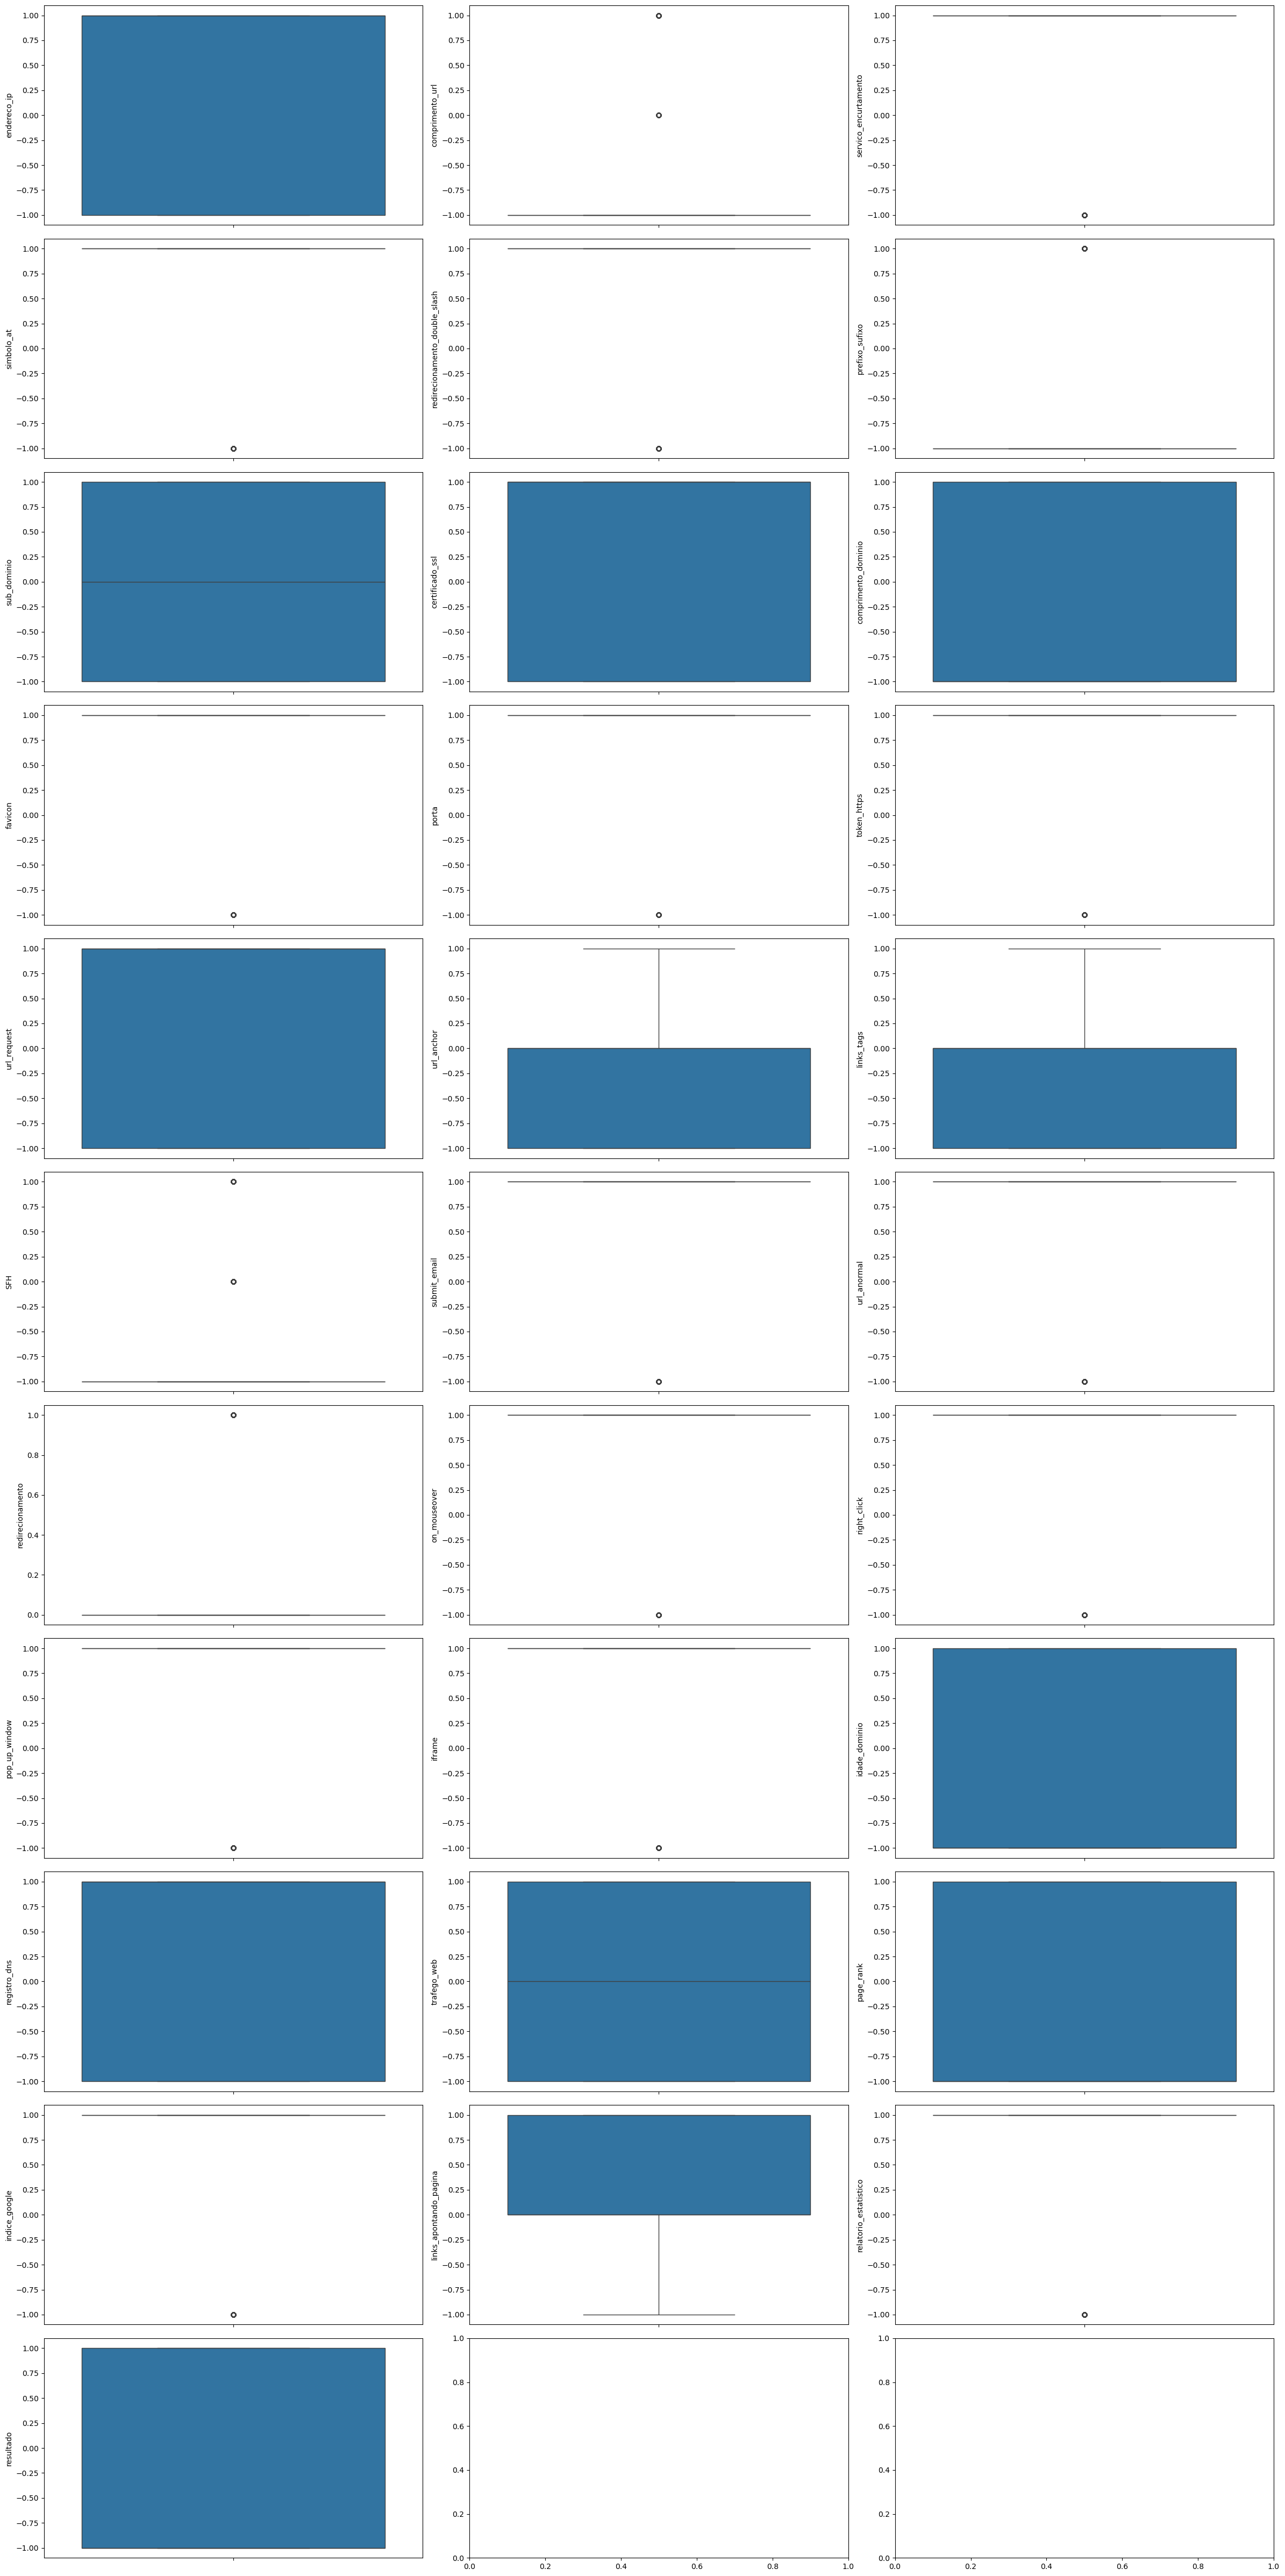

In [17]:
# verificando se temos outliers
names = list(dados.columns)
f, axes = plt.subplots(round(len(names) / 3) + 1, 3, figsize = (24, 48))
y = 0 
for name in names:
    i, j = divmod(y, 3)
    sns.boxplot(y = dados[name], ax = axes[i, j])
    y = y + 1

plt.tight_layout()
plt.show()

In [18]:
#checando valores únicos de cada variável
for col_name in dados.columns:
    print('A variável [' + col_name + '] tem', dados[col_name].nunique(), 
          'valores únicos, que são:', dados[col_name].unique())

A variável [endereco_ip] tem 2 valores únicos, que são: [-1  1]
A variável [comprimento_url] tem 3 valores únicos, que são: [ 1  0 -1]
A variável [servico_encurtamento] tem 2 valores únicos, que são: [ 1 -1]
A variável [simbolo_at] tem 2 valores únicos, que são: [ 1 -1]
A variável [redirecionamento_double_slash] tem 2 valores únicos, que são: [-1  1]
A variável [prefixo_sufixo] tem 2 valores únicos, que são: [-1  1]
A variável [sub_dominio] tem 3 valores únicos, que são: [-1  0  1]
A variável [certificado_ssl] tem 3 valores únicos, que são: [-1  1  0]
A variável [comprimento_dominio] tem 2 valores únicos, que são: [-1  1]
A variável [favicon] tem 2 valores únicos, que são: [ 1 -1]
A variável [porta] tem 2 valores únicos, que são: [ 1 -1]
A variável [token_https] tem 2 valores únicos, que são: [-1  1]
A variável [url_request] tem 2 valores únicos, que são: [ 1 -1]
A variável [url_anchor] tem 3 valores únicos, que são: [-1  0  1]
A variável [links_tags] tem 3 valores únicos, que são: [ 1

### Análise de correlação

- A coluna resultado será nossa varável de saída e as demais variável de entrada
- Precisamos de uma alta correlação entre as variáveis preditoras e a variável alvo (resultado), mas queremos uma baixa correlação dentre as variáveis preditoras

In [19]:
corr = dados.corr()
corr

,endereco_ip,comprimento_url,servico_encurtamento,simbolo_at,redirecionamento_double_slash,prefixo_sufixo,sub_dominio,certificado_ssl,comprimento_dominio,favicon,...,pop_up_window,iframe,idade_dominio,registro_dns,trafego_web,page_rank,indice_google,links_apontando_pagina,relatorio_estatistico,resultado
endereco_ip,1.000000,-0.038320,0.316050,0.148540,0.305726,0.020593,-0.073633,0.065495,-0.010409,0.077500,...,0.091370,0.051756,-0.001155,-0.091961,-0.003595,-0.097105,0.008106,-0.315630,-0.051005,0.095586
comprimento_url,-0.038320,1.000000,-0.115106,-0.062763,-0.086178,0.065774,-0.011812,0.045471,-0.223230,-0.004520,...,-0.016653,0.004899,0.246596,-0.043408,0.005420,0.174315,-0.003547,-0.035851,-0.032840,0.054015
servico_encurtamento,0.316050,-0.115106,1.000000,0.116086,0.814745,-0.078495,-0.054725,-0.068507,0.066999,-0.002292,...,0.031845,0.020605,-0.058390,0.470354,-0.039705,-0.001255,0.206032,-0.186796,0.039821,-0.080312
simbolo_at,0.148540,-0.062763,0.116086,1.000000,0.099836,-0.015577,-0.048767,0.025959,0.021060,0.358670,...,0.339844,0.324146,-0.001648,-0.028651,0.010905,-0.060400,0.022587,-0.018967,-0.082191,0.042589
redirecionamento_double_slash,0.305726,-0.086178,0.814745,0.099836,1.000000,-0.083503,-0.058469,-0.042536,0.050218,0.021740,...,0.043527,0.012884,-0.059706,0.463915,-0.050889,-0.016505,0.237099,-0.166590,0.021893,-0.043130
prefixo_sufixo,0.020593,0.065774,-0.078495,-0.015577,-0.083503,1.000000,0.096136,0.278662,-0.109733,-0.015390,...,-0.013658,-0.044058,0.074979,-0.024002,0.127665,-0.014350,0.061811,0.076355,0.014425,0.378866
sub_dominio,-0.073633,-0.011812,-0.054725,-0.048767,-0.058469,0.096136,1.000000,0.246312,-0.082531,-0.027635,...,-0.032604,0.005603,0.044671,0.090762,-0.032569,0.098199,0.073698,0.019415,0.086878,0.276641
certificado_ssl,0.065495,0.045471,-0.068507,0.025959,-0.042536,0.278662,0.246312,1.000000,-0.186487,-0.027667,...,-0.023895,-0.007737,0.134766,0.025369,0.247840,0.013925,0.073996,0.018522,0.093249,0.693899
comprimento_dominio,-0.010409,-0.223230,0.066999,0.021060,0.050218,-0.109733,-0.082531,-0.186487,1.000000,0.060647,...,0.058324,0.004105,-0.076738,0.011803,-0.124376,-0.051296,-0.028812,0.103261,-0.023100,-0.227927
favicon,0.077500,-0.004520,-0.002292,0.358670,0.021740,-0.015390,-0.027635,-0.027667,0.060647,1.000000,...,0.933508,0.616087,-0.008794,0.055602,-0.064450,0.022094,-0.022421,-0.118695,0.207202,-0.022675


In [56]:
#sns.set(rc = {'figure.figsize':(32,16)})
#sns.heatmap(corr, annot = True);

Vamos listar as 10 variáveis com maior correlação para melhor visualização

In [21]:
dados_correlacao = corr[corr < 1].unstack().sort_values(ascending = False).drop_duplicates().head(10)
dados_correlacao

favicon                        pop_up_window                    0.933508
redirecionamento_double_slash  servico_encurtamento             0.814745
favicon                        porta                            0.808149
porta                          submit_email                     0.783704
                               pop_up_window                    0.750848
pop_up_window                  on_mouseover                     0.731892
token_https                    redirecionamento_double_slash    0.730376
                               servico_encurtamento             0.730345
url_anormal                    servico_encurtamento             0.709091
certificado_ssl                resultado                        0.693899
dtype: float64

In [22]:
# determinar um limite 
corr_threshold = .8

In [23]:
#correlacao acima do limite
dados_correlacao[dados_correlacao > corr_threshold]

favicon                        pop_up_window           0.933508
redirecionamento_double_slash  servico_encurtamento    0.814745
favicon                        porta                   0.808149
dtype: float64

In [24]:
# A variável favicon tem alta correlação com outras duas e pode ser removida
del dados['favicon']

In [25]:
# Removemos ainda a variável redirecionamento_double_slash
del dados['redirecionamento_double_slash']

In [26]:
#correlacao acima do limite
corr = dados.corr()
dados_correlacao = corr[corr < 1].unstack().sort_values(ascending = False).drop_duplicates().head(10)
dados_correlacao[dados_correlacao > corr_threshold]

dados.shape

(5389, 29)

In [27]:
# Vamos checar o desvio padrão das variáveis
# Colunas com desvio padrão igual a zero são na verdade constantes e não variáveis
# Constantes devem ser removidas do dataset
cols_to_drop = []
for each_col in dados.drop(['resultado'], axis = 1).columns:
    if dados[each_col].dtypes !='O':
        if dados[each_col].std() == 0.00:
            stats= each_col + ' { ' \
            ' std : ' + str(df[each_col].std()) + \
            ' Min : ' + str(df[each_col].min()) + \
            ' Max : ' + str(df[each_col].max()) + " } "
            print(stats)
            cols_to_drop.append(each_col)

print('Numero de colunas com desvio padrão igual a zero: {}'.format(len(cols_to_drop)))

Numero de colunas com desvio padrão igual a zero: 0


## Redução de Dimensionalidade com PCA
Estratégia de Processamento dos Dados
- Vamos reduzir a dimensiolidade dos dados
- O PCA faz isso calculando a matriz de covariancia entre as variaveis, depois o PCA encontra uma matriz final, calcula auto valor e auto vetor e isso nos dá os componentes principais

In [28]:
dados.head()

,endereco_ip,comprimento_url,servico_encurtamento,simbolo_at,prefixo_sufixo,sub_dominio,certificado_ssl,comprimento_dominio,porta,token_https,...,pop_up_window,iframe,idade_dominio,registro_dns,trafego_web,page_rank,indice_google,links_apontando_pagina,relatorio_estatistico,resultado
0,-1,1,1,1,-1,-1,-1,-1,1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,-1,0,1,-1,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,-1,-1,-1,-1,1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,-1,-1,-1,1,1,-1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,-1,1,1,-1,1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [29]:
# dividindo em x e y
X = dados.iloc[:,0:28].values
X.shape

(5389, 28)

In [30]:
y = dados.iloc[:,28].values
y.shape

(5389,)

In [31]:
# Treino e teste proporção 80/20
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.2, random_state = 0)  

Criaremos 3 modelos de PCA com diferentes números de componentes

### PCA Full

In [32]:
modelo_pca_full = PCA()

X_treino_pca_full = modelo_pca_full.fit_transform(X_treino)
X_teste_pca_full = modelo_pca_full.transform(X_teste)

In [33]:
variancia_explicada_pca_full = modelo_pca_full.explained_variance_ratio_
print(variancia_explicada_pca_full)

[0.13944874 0.11432987 0.09745131 0.07247741 0.06509672 0.05920247
 0.04534875 0.04073999 0.03688374 0.03552341 0.03122291 0.0290447
 0.02845579 0.0266385  0.02384772 0.02178961 0.02066376 0.01800354
 0.01605577 0.01408206 0.01286235 0.01189816 0.00980355 0.00820845
 0.00641045 0.00525543 0.00471895 0.00453588]


Cada numero desse é um componente principal, eles representam o total da variancia explicada pelo componente.
- O Primeiro componente explica 13.9% da variância dos dados
- O segundo explica 11%
- etc

In [34]:
len(variancia_explicada_pca_full)

28

Este é o número de componentes principais, tinhamos 29 agora 28, não ficou bom este modelo pois deveria reduzir mais a dimensionalidade

### PCA 10 Componentes

In [35]:
# Criamos o modelo com 10 componentes principais 
modelo_pca_10 = PCA(n_components = 10)
X_treino_pca_10 = modelo_pca_10.fit_transform(X_treino)  
X_teste_pca_10 = modelo_pca_10.transform(X_teste) 
variancia_explicada_pca_10 = modelo_pca_10.explained_variance_ratio_  

In [36]:
print(variancia_explicada_pca_10)

[0.13944874 0.11432987 0.09745131 0.07247741 0.06509672 0.05920247
 0.04534875 0.04073999 0.03688374 0.03552341]


In [37]:
len(variancia_explicada_pca_10)

10

Agora o ocorreu o oposto, reduziu muito e com essa quantidade não consigo explicar a variabilidade dos dados

### PCA 5 Componentes

In [38]:
#%%
# Criamos o modelo com 5 componentes principais 
modelo_pca_5 = PCA(n_components = 5)
X_treino_pca_5 = modelo_pca_5.fit_transform(X_treino)  
X_teste_pca_5 = modelo_pca_5.transform(X_teste) 
variancia_explicada_pca_5 = modelo_pca_5.explained_variance_ratio_ 

print(variancia_explicada_pca_5)

[0.13944874 0.11432987 0.09745131 0.07247741 0.06509672]


In [39]:
len(variancia_explicada_pca_5)

5

## Modelagem Preditiva com cada um dos PCAs

Usaremos Regressão Logística pois nosso problema é de classificação. Dada uma URL nosso modelo deve ser capaz de prever se ela pertencerá a uma de duas classes, phishing ou legítima. A variável alvo é a variável **resultado** no conjunto de dados.
A Regressão Logística é um dos mais poderosos modelos de Machine Learning para classificação.

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

### Primeira versao SEM o PCA

In [40]:
modelo_classificador_v1 = LogisticRegression()

modelo_classificador_v1.fit(X_treino, y_treino)

LogisticRegression()

In [41]:
y_pred_v1 = modelo_classificador_v1.predict(X_teste)  
print('Acurácia da Versão 1 do Modelo:', metrics.accuracy_score(y_teste, y_pred_v1))

Acurácia da Versão 1 do Modelo: 0.9257884972170687


In [42]:
# Confusion Matrix
cm = confusion_matrix(y_teste, y_pred_v1) 
print(cm)  

[[486  40]
 [ 40 512]]


## Versão 2 utilizando PCA Full

In [43]:
modelo_classificador_v2 = LogisticRegression()
modelo_classificador_v2.fit(X_treino_pca_full, y_treino)

LogisticRegression()

In [44]:
y_pred_v2 = modelo_classificador_v2.predict(X_teste_pca_full)  
print('Acurácia da Versão 2 do Modelo:', metrics.accuracy_score(y_teste, y_pred_v2))

Acurácia da Versão 2 do Modelo: 0.9257884972170687


In [45]:
cm = confusion_matrix(y_teste, y_pred_v2) 
print(cm)  

[[486  40]
 [ 40 512]]


## Versão 3 utilizando PCA 10 Componentes

In [46]:
modelo_classificador_v3 = LogisticRegression()
modelo_classificador_v3.fit(X_treino_pca_10, y_treino)

LogisticRegression()

In [47]:
y_pred_v3 = modelo_classificador_v3.predict(X_teste_pca_10) 
print('Acurácia da Versão 3 do Modelo:', metrics.accuracy_score(y_teste, y_pred_v3))

Acurácia da Versão 3 do Modelo: 0.9137291280148423


In [48]:
cm = confusion_matrix(y_teste, y_pred_v3) 
print(cm)  

[[472  54]
 [ 39 513]]


## Versão 4 utilizando PCA 5 Componentes

In [49]:
modelo_classificador_v4 = LogisticRegression()
modelo_classificador_v4.fit(X_treino_pca_5, y_treino)

LogisticRegression()

In [50]:
y_pred_v4 = modelo_classificador_v4.predict(X_teste_pca_5)  
print('Acurácia da Versão 4 do Modelo:', metrics.accuracy_score(y_teste, y_pred_v4))

Acurácia da Versão 4 do Modelo: 0.9165120593692022


In [51]:
cm = confusion_matrix(y_teste, y_pred_v4) 
print(cm) 

[[474  52]
 [ 38 514]]


A perfomance ficou bem parecida com um número de componentes principais, seria interessante essa abordagem para fazer um deploy, ficaria mais leve o modelo pois só precisaria alimentá-lo com 5 componentes principais

### Realizar GridSearch para verificar com quantos parametros o modelo classifica melhor

In [52]:
pca = PCA()
classifier = LogisticRegression()
pipe = Pipeline(steps=[("pca", pca), ("classifier", classifier)])

# Cria o grid com o número de componentes princiais para testar
param_grid = {"pca__n_components": [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28]}

In [53]:
# Cria o buscador com GridSearchCV
buscador = GridSearchCV(pipe, param_grid, n_jobs = -1, cv = 2, verbose = 1)
buscador.fit(X_treino, y_treino)

Fitting 2 folds for each of 28 candidates, totalling 56 fits


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('pca', PCA()),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'pca__n_components': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                                               11, 12, 13, 14, 15, 16, 17, 18,
                                               19, 20, 21, 22, 23, 24, 25, 26,
                                               27, 28]},
             verbose=1)

In [54]:
print("Melhor Performance Obtida (CV score=%0.3f):" % buscador.best_score_)
print(buscador.best_params_)

Melhor Performance Obtida (CV score=0.919):
{'pca__n_components': 26}


O modelo de benchmarking (versão 1) apresentou ótima performance, mas sem realizar validação cruzada. O modelo com Grid Searching obteve quase a mesma performance mas com dimensionalidade menor dos dados, o que deixaria o modelo mais simples e tornaria o processo de treinamento mais rápido. PCA com 26 componentes principais parece ser o ideal para este cenário e seguiremos em frente com esse valor.

## Checando a variância explicada pelos componentes principais

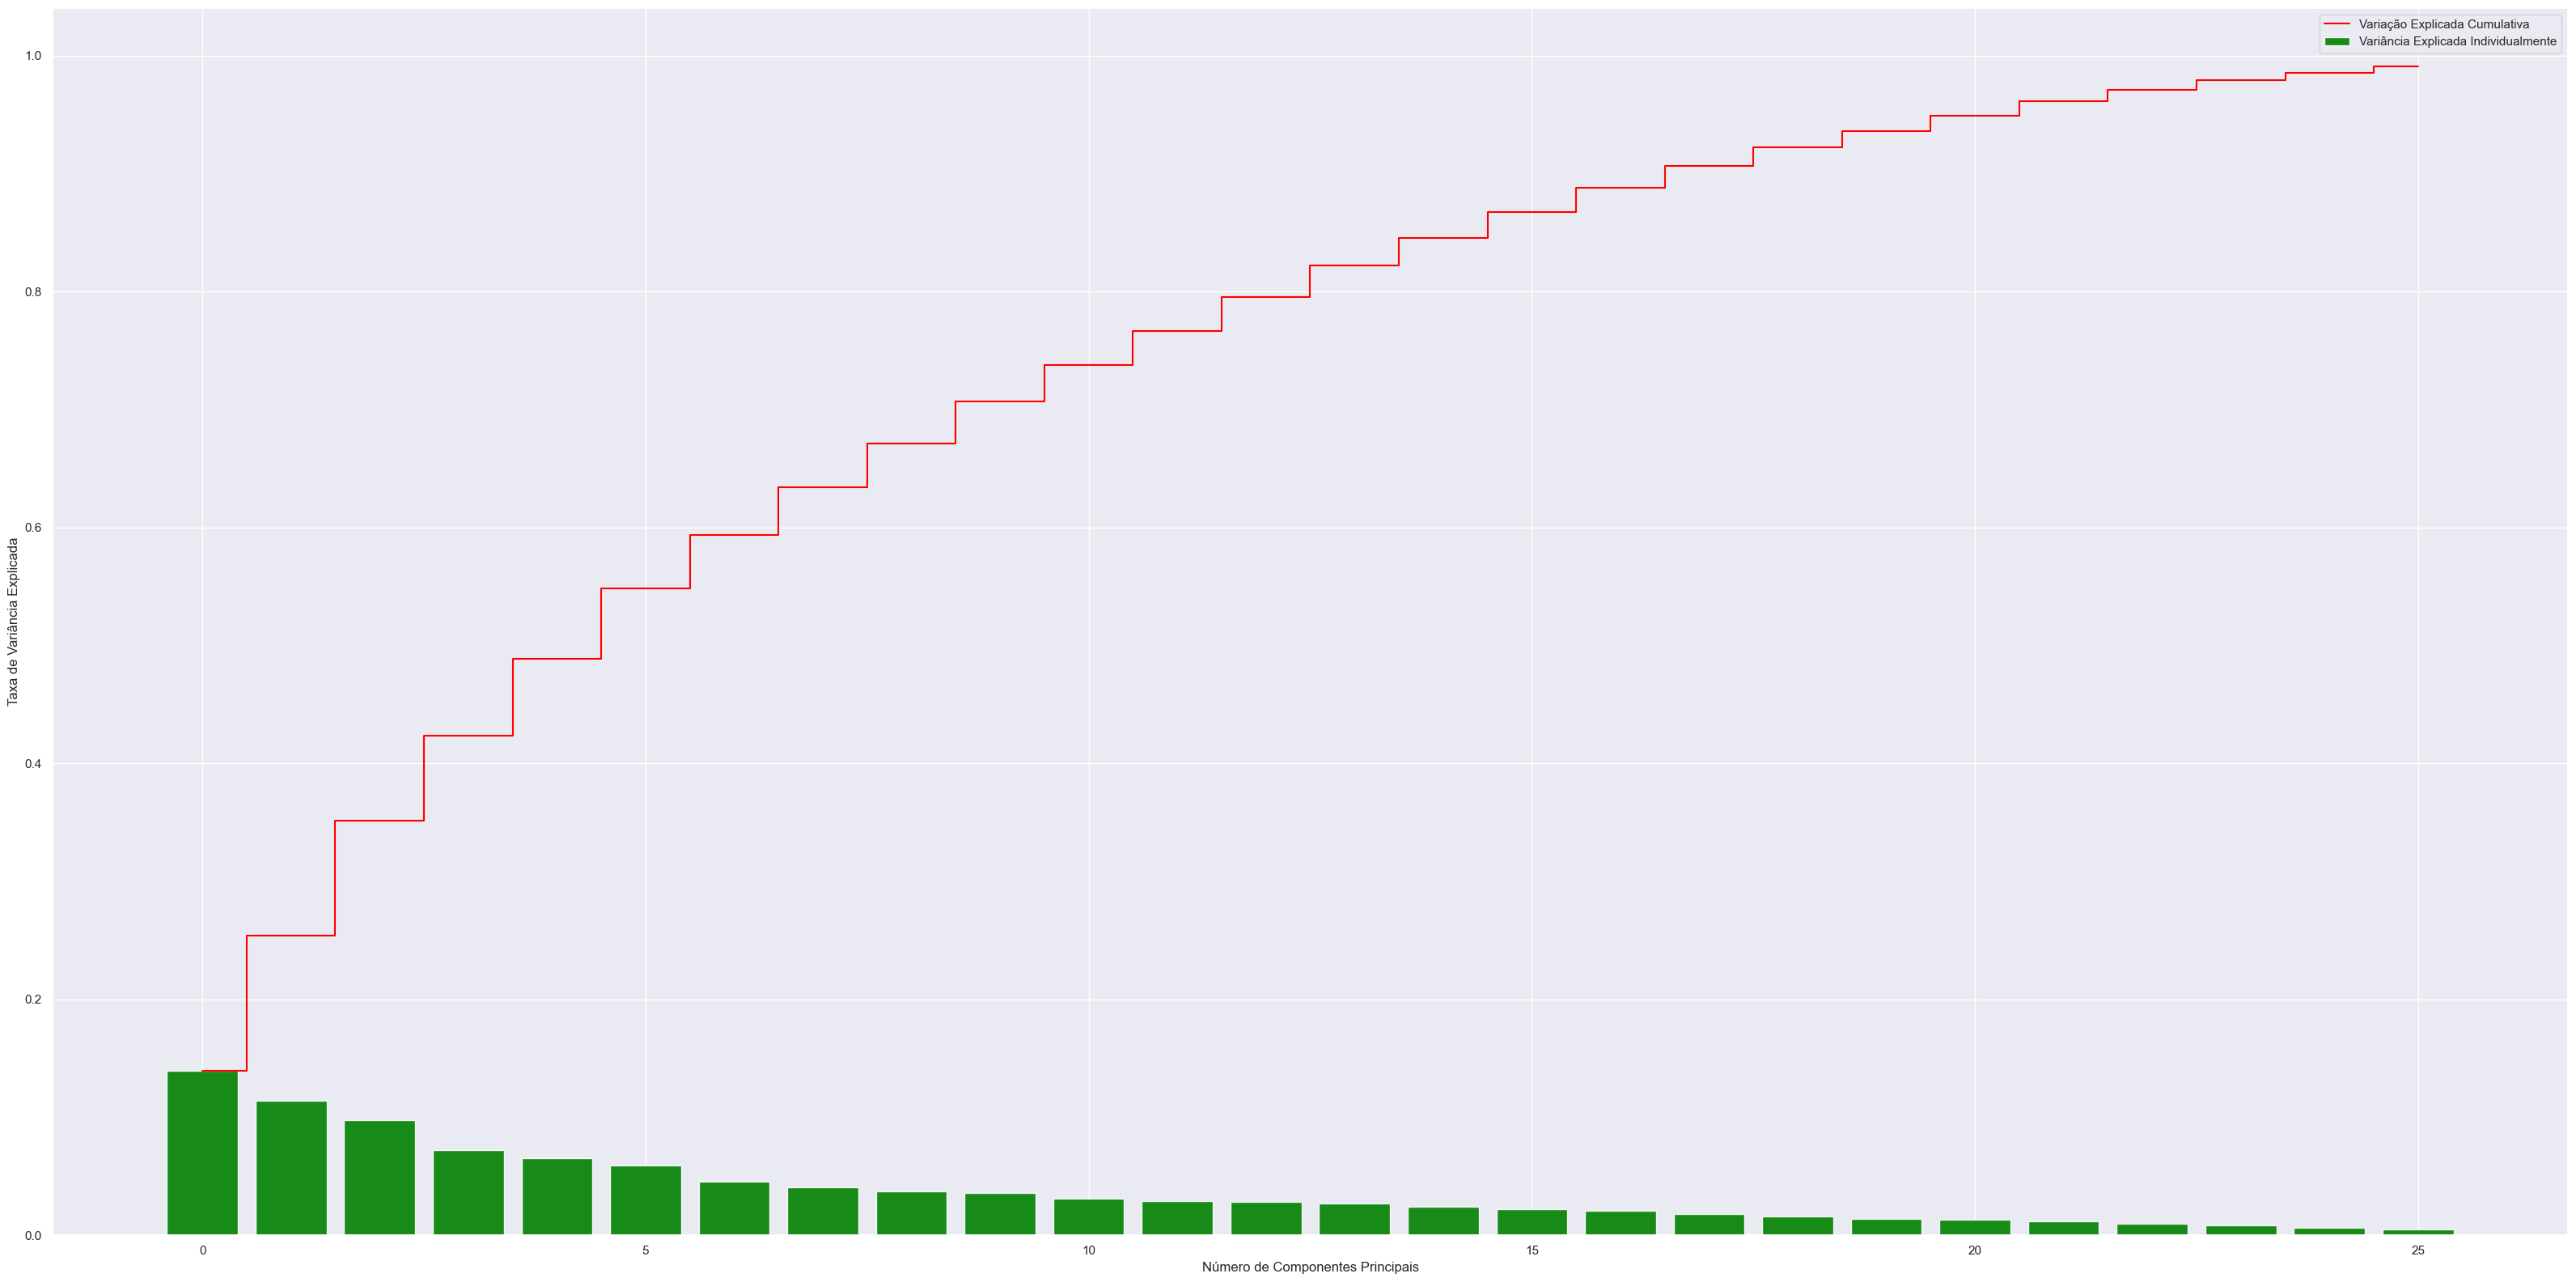

In [57]:
# Cria o modelo PCA
pca = PCA(n_components = 26)

# Treina o modelo
pca.fit(X_treino)

# Extrai a variância explicada
var_exp_pca = pca.explained_variance_ratio_

# Calcula a soma acumulada
soma_acumulada_var_exp_pca = np.cumsum(var_exp_pca)

# Plot
plt.bar(range(0, len(var_exp_pca)), var_exp_pca, 
        alpha = 0.9, 
        align = 'center', 
        color = 'green',
        label = 'Variância Explicada Individualmente')
plt.step(range(0,len(soma_acumulada_var_exp_pca)), soma_acumulada_var_exp_pca, 
         where = 'mid',
         color = 'red',
         label = 'Variação Explicada Cumulativa')
plt.ylabel('Taxa de Variância Explicada')
plt.xlabel('Número de Componentes Principais')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Versão 5 do Modelo Usando o Número Ideal de Componentes Principais

In [58]:
# Cria o modelo PCA
pca = PCA(n_components = 26)

# Fit e Transform
X_treino_v5 = pca.fit_transform(X_treino)  
X_teste_v5 = pca.transform(X_teste) 

# Cria o classificador
modelo_classificador_v5 = LogisticRegression()

# Treina o classificador
modelo_classificador_v5.fit(X_treino_v5, y_treino)

# Previsões com dados de teste
y_pred_v5 = modelo_classificador_v5.predict(X_teste_v5)  

print('Acurácia da Versão 5 do Modelo:', metrics.accuracy_score(y_teste, y_pred_v5))

# Confusion Matrix
cm = confusion_matrix(y_teste, y_pred_v5)  
print(cm)  

Acurácia da Versão 5 do Modelo: 0.9239332096474954
[[487  39]
 [ 43 509]]


## Avaliação do Modelo com a Curva ROC

Modelo Mínimo: ROC AUC = 0.500
Nosso Modelo: ROC AUC = 0.978


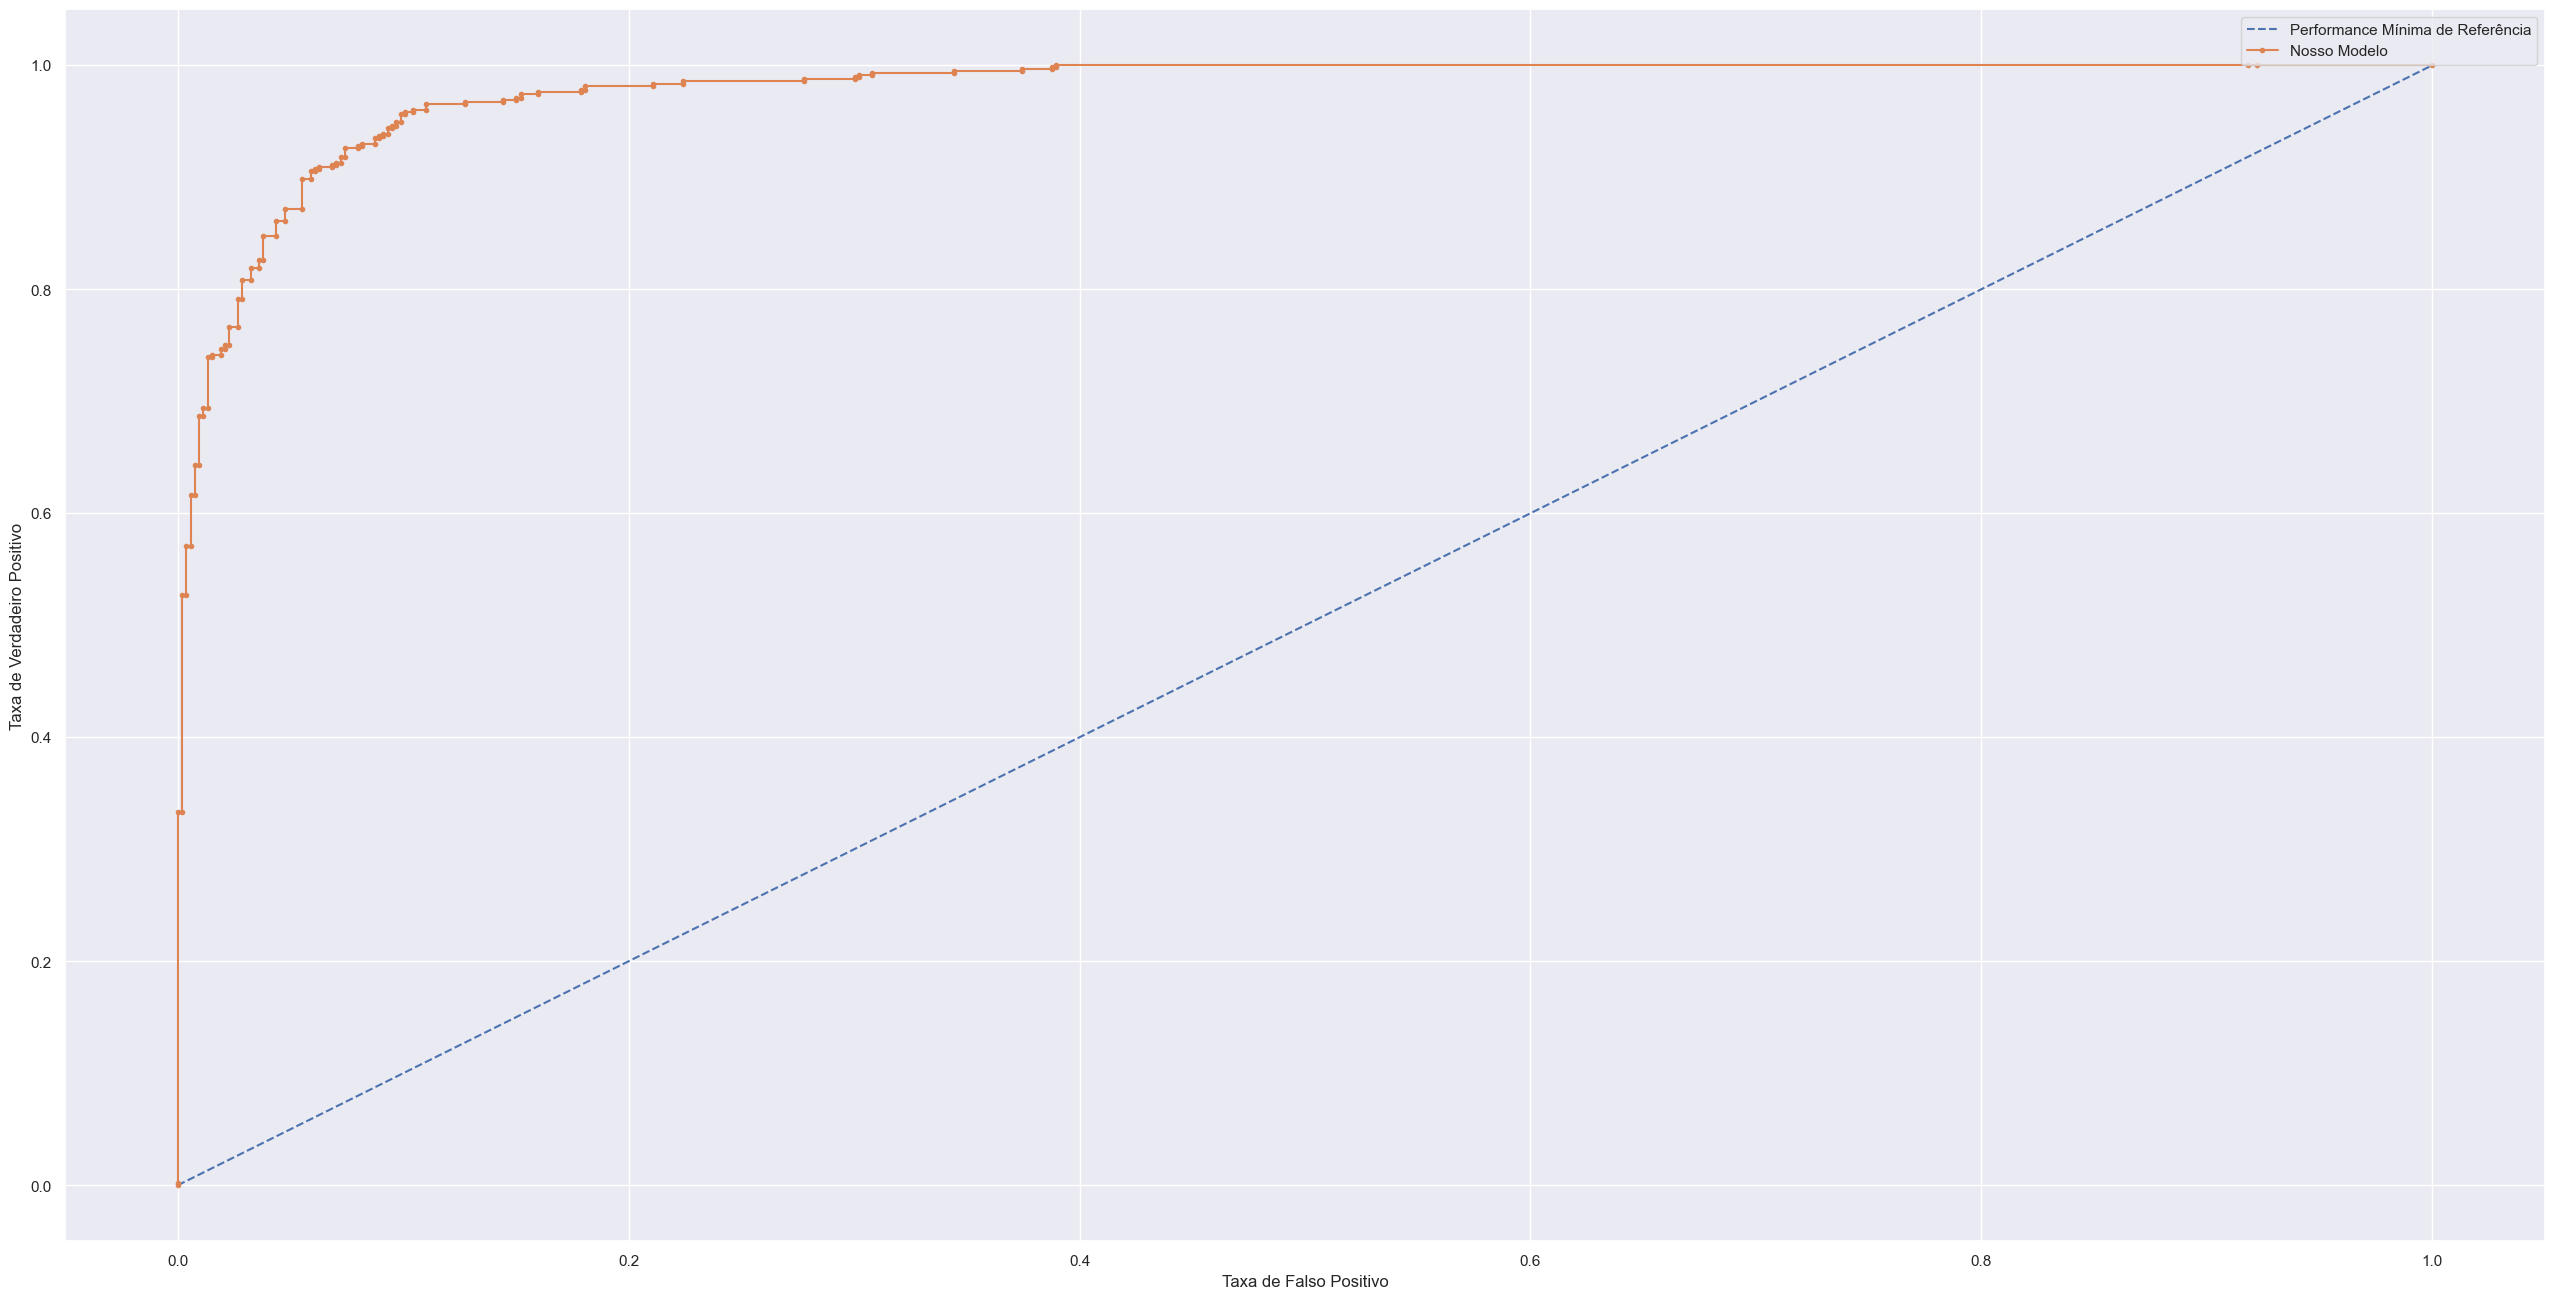

In [59]:
# Cria um modelo sem treinamento (referência mínima)
ref_probs = [0 for _ in range(len(y_teste))]

# Faz as previsões com o nosso modelo
lr_probs = modelo_classificador_v5.predict_proba(X_teste_v5)

# Mantém as probabilidades apenas para o resultado positivo
lr_probs = lr_probs[:, 1]

# Calcula os scores
ref_auc = roc_auc_score(y_teste, ref_probs)
lr_auc = roc_auc_score(y_teste, lr_probs)

# Sumário
print('Modelo Mínimo: ROC AUC = %.3f' % (ref_auc))
print('Nosso Modelo: ROC AUC = %.3f' % (lr_auc))

# Calcula Curva ROC
ref_fpr, ref_tpr, _ = roc_curve(y_teste, ref_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_teste, lr_probs)

# Plot
plt.plot(ref_fpr, ref_tpr, linestyle = '--', label = 'Performance Mínima de Referência')
plt.plot(lr_fpr, lr_tpr, marker = '.', label = 'Nosso Modelo')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.legend()
plt.show()

### Otimização de hiperparâmetros

In [60]:
%%time

# Define o modelo 
modelo = LogisticRegression()

# Define os hiperparâmetros
solvers = ['newton-cg', 'lbfgs', 'liblinear']
penalty = ['l2']
c_values = [100, 10, 1.0, 0.1, 0.01]

# Define o grid 
grid = dict(solver = solvers, penalty = penalty, C = c_values)

# Cross Validation
cv = RepeatedStratifiedKFold(n_splits = 10, n_repeats = 3, random_state = 1)

# Grid search
grid_search = GridSearchCV(estimator = modelo, 
                           param_grid = grid, 
                           n_jobs = -1, 
                           cv = cv, 
                           scoring = 'accuracy',
                           error_score = 0)

# Resultado do grid search
resultado = grid_search.fit(X_treino_v5, y_treino)

# Sumário
print("Melhor Performance: %f usando %s" % (resultado.best_score_, resultado.best_params_))
print('\n')
means = resultado.cv_results_['mean_test_score']
stds = resultado.cv_results_['std_test_score']
params = resultado.cv_results_['params']

# Loop pelos resultados
for mean, stdev, param in zip(means, stds, params):
    print("Performance = %f (%f) com estes hiperparâmetros: %r" % (mean, stdev, param))

print('\n')

Melhor Performance: 0.920589 usando {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}


Performance = 0.919506 (0.011843) com estes hiperparâmetros: {'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
Performance = 0.919661 (0.012554) com estes hiperparâmetros: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Performance = 0.919815 (0.012472) com estes hiperparâmetros: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Performance = 0.919429 (0.011626) com estes hiperparâmetros: {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}
Performance = 0.919506 (0.011752) com estes hiperparâmetros: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Performance = 0.919506 (0.011690) com estes hiperparâmetros: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Performance = 0.919661 (0.011982) com estes hiperparâmetros: {'C': 1.0, 'penalty': 'l2', 'solver': 'newton-cg'}
Performance = 0.919661 (0.011982) com estes hiperparâmetros: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Performance = 0.919661 (0.0119

### Versão do Modelo com os melhores Hiperparâmetros

In [61]:
%%time

# Métrica
scoring = {'accuracy': 'accuracy'}

# Versão final do modelo
modelo_best_hyp = LogisticRegression(C = 0.1, penalty = 'l2', solver = 'newton-cg')

# Kfold
kf = KFold(n_splits = 11, shuffle = True, random_state = 20)

# Cross Validate
scores = cross_validate(estimator = modelo_best_hyp, 
                        X = X_treino_v5, 
                        y = y_treino, 
                        cv = kf, 
                        scoring = scoring, 
                        return_train_score = True)

print('\nAcurácia em Treino: {}'.format(scores['train_accuracy'].mean()))
print('Acurácia em Teste: {}'.format(scores['test_accuracy'].mean()))


Acurácia em Treino: 0.9220830822296211
Acurácia em Teste: 0.9190464723438783
CPU times: user 66.9 ms, sys: 12 ms, total: 78.9 ms
Wall time: 77.6 ms


# Versão Final do modelo

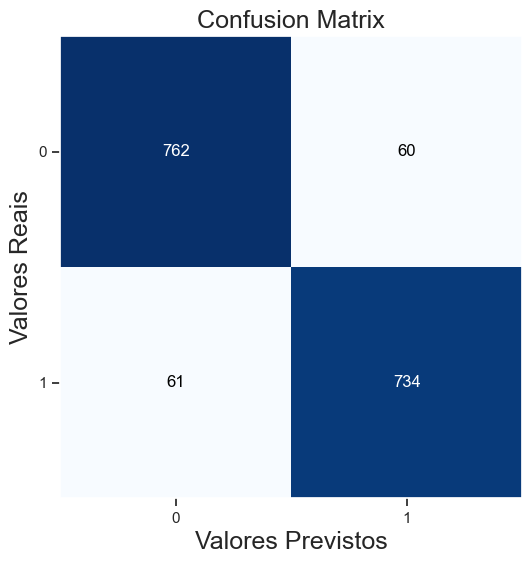

Acurácia da Versão Final do Modelo: 0.9251700680272109


In [62]:
# Recria os datasets de treino e teste (observe a mudança de proporção)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.3, random_state = 7)  

# Modelo PCA
pca = PCA(n_components = 26)

# Fit e Transform em Treino
X_treino_final = pca.fit_transform(X_treino)  

# Transform em Teste
X_teste_final = pca.transform(X_teste) 

# Cria o modelo
modelo_versao_final = LogisticRegression(C = 0.1, penalty = 'l2', solver = 'newton-cg')

# Treina o modelo
modelo_versao_final.fit(X_treino_final, y_treino)

# Previsões
y_pred_final = modelo_versao_final.predict(X_teste_final)  

# Matriz de confusão
cm = confusion_matrix(y_teste, y_pred_final)  
 
# Plot
fig, ax = plot_confusion_matrix(conf_mat = cm, figsize = (8, 6), cmap = plt.cm.Blues)
plt.xlabel('Valores Previstos', fontsize = 18)
plt.ylabel('Valores Reais', fontsize = 18)
plt.title('Confusion Matrix', fontsize = 18)
plt.show()
print('Acurácia da Versão Final do Modelo:', metrics.accuracy_score(y_teste, y_pred_final))

In [63]:
print(classification_report(y_teste, y_pred_final))

              precision    recall  f1-score   support

          -1       0.93      0.93      0.93       822
           1       0.92      0.92      0.92       795

    accuracy                           0.93      1617
   macro avg       0.93      0.93      0.93      1617
weighted avg       0.93      0.93      0.93      1617



### Salvando

In [65]:
dump(pca, 'modelo/modelo_pca.joblib') 

['modelo/modelo_pca.joblib']

In [66]:
dump(modelo_versao_final, 'modelo/modelo_versao_final.joblib') 

['modelo/modelo_versao_final.joblib']

In [67]:
%watermark -v -m

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 8.30.0

Compiler    : Clang 14.0.6 
OS          : Darwin
Release     : 25.0.0
Machine     : arm64
Processor   : arm
CPU cores   : 10
Architecture: 64bit



In [68]:
%watermark --iversions

json      : 2.0.9
sklearn   : 1.6.1
joblib    : 1.4.2
seaborn   : 0.13.2
numpy     : 2.1.3
matplotlib: 3.10.0
mlxtend   : 0.23.4
pandas    : 2.2.3

